<a href="https://colab.research.google.com/github/JuandeDiosMG/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage

print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
- En la base de datos se tiene que trabajar con las columnas city con un 0.11 se tiene que imputar o dejar como nulos y en la columna Churn con un 0.88 se tiene que ignorar
- En la base de datos usage se tieneque trabajar con la columna duration con un 0.55 y lengeth con un 0.44 por lo tanto considero que ambas columnas se tienen que ignorar


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
print(users["user_id"].describe())
print(users["age"].describe())

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` el comportamiento se ve estable por lo tanto pareciera que no tiene problemas
- La columna `age`encontramos un valor atipico como valor minimo, entonces se tiene que corregir

In [ ]:
# explorar columnas numéricas de usage

print(usage["user_id"].describe())
print(usage["id"].describe())
print(usage["duration"].describe())
print(usage["length"].describe())

count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64
count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
count    17924.000000
mean         5.202237
std          6.842701
min          0.000000
25%          1.437500
50%          3.500000
75%          6.990000
max        120.000000
Name: duration, dtype: float64
count    22104.000000
mean        52.127398
std         56.611183
min          0.000000
25%         37.000000
50%         50.000000
75%         64.000000
max       1490.000000
Name: length, dtype: float64


- Las columnas `id` y `user_id`observamos una distribución normal entre ambos datos, por lo tanto no se objercan comportamientos extraños entre los datos
- Las columnas las columnasm lengh y duration tienen muchas valores faltantes y la diferencia entre el mínimo y maximo es bastante grande lo que genera ruido a la información

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users['city'].describe())
print(users["plan"].describe())

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object
count       4000
unique         2
top       Basico
freq        2595
Name: plan, dtype: object


- La columna `city`, encontramos 7 valores unicos de los cuales el de mayor frecuencia es el de la Ciudad de Bogotá, sin embargo los datos no se encuentran completos debido a que existen por lo menos 500 no registrados
- La columna `plan`, encontramos dos tipos de variables paquete basico y premium donde el mas común es el paquete basico

In [ ]:
# explorar columna categórica de usage
usage['type'] # completa el código
print(usage["type"].describe())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object


- La columna `type` se encuentran dos tipos de valores de los cuales aquel con mayor frecuencia es de tipo texto


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- La filas de ciudad, duracion y length son aquellos que tienen mayor cantidad de sentinels
- ¿Qué acción tomarías?
- Ignoraria las filas duration y length, y corregiria los sentinels en la fila city

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"])

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"])

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, el año 2026 esta mal registrado debido a que es un año que esta ocurriendo

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, tiene un problema que es el punto despues del 2024 y agegar bien los valores no validos
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- aparece el año 2026 ya que no ha trascurrido
- ¿Qué harías con ellas?
- Los marcaria como valor invalido o los cambiaria por el año más común[]

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age

age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)


# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", "NA")

# Verificar cambios
users["city"].describe


<bound method NDFrame.describe of 0       Medellín
1             NA
2           CDMX
3         Bogotá
4            GDL
          ...   
3995    Medellín
3996    Medellín
3997      Bogotá
3998      Bogotá
3999      Bogotá
Name: city, Length: 4000, dtype: object>

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users["reg_date"].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
print("=== Análisis MAR para DURATION ===")
print("Valores no nulos por tipo:")
print(usage.groupby('type')['duration'].count())
print("\nTotal de registros por tipo:")
print(usage.groupby('type').size())

=== Análisis MAR para DURATION ===
Valores no nulos por tipo:
type
call    17908
text       16
Name: duration, dtype: int64

Total de registros por tipo:
type
call    17908
text    22092
dtype: int64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
print("\n=== Análisis MAR para LENGTH ===")
print("Valores no nulos por tipo:")
print(usage.groupby('type')['length'].count())
print("\nTotal de registros por tipo:")
print(usage.groupby('type').size())


=== Análisis MAR para LENGTH ===
Valores no nulos por tipo:
type
call       12
text    22092
Name: length, dtype: int64

Total de registros por tipo:
type
call    17908
text    22092
dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Se nota que la los datos de duaracion y tamaño de texto estan relacionado con la variable tipo, debido a que cuando el tipo es llamda solo se puede registrar la duracion de la llamada, mientras cuando el tipo es texto solo se puede registrar tamaño de texto. Por lo tanto las variables se tienen que tomar como datos nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
 'is_text':'sum',
    "is_call":'sum',
    'duration':'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={
    'is_text':'cant_mensajes',
    'is_call':'cant_llamadas',
    'duration':'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  

1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [ ]:
# Resumen estadístico de las columnas numéricas
#user_profile.info()
print('cant_mensajes' ,user_profile['cant_mensajes'].describe())
print('cant_llamadas' ,user_profile['cant_llamadas'].describe())
print('cant_minutos_llamada' ,user_profile['cant_minutos_llamada'].describe())
print('age' ,user_profile['age'].describe())

cant_mensajes count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64
cant_llamadas count    3999.000000
mean        4.478120
std         2.144238
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        15.000000
Name: cant_llamadas, dtype: float64
cant_minutos_llamada count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64
age count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).round(3) * 100

Basico     64.9
Premium    35.1
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

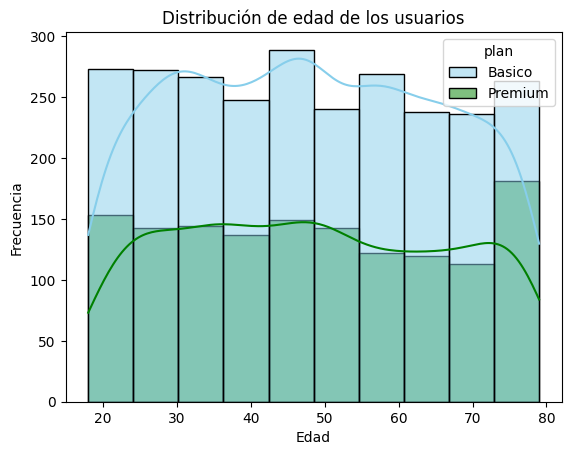

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age',  hue="plan", palette=['skyblue', 'green'], bins=10,kde=True)
plt.xlabel('Edad')
plt.ylabel("Frecuencia")
plt.title("Distribución de edad de los usuarios")
plt.show()


💡Insights:
- Distribución es líneal ya que no observamos mucha variación entre las edades. Si se pudiera observar un patron mayor es en los clientes con una edad entre 40 y  50 años. Observamos que los clientes entre 70 y 80 años son los que tienen en mayoria paquete basico

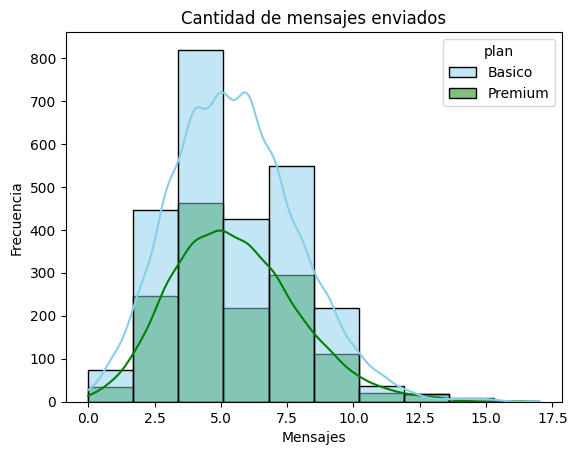

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', bins=10, hue="plan", palette=['skyblue', 'green'] ,kde=True)
plt.xlabel('Mensajes')
plt.ylabel("Frecuencia")
plt.title("Cantidad de mensajes enviados")
plt.show()


💡Insights:
- La distrubución se muestra normal con segmentación a la deracha. La mayoria de los clientes de ambos paquetes envian entre 2.5 y 5 mesajes

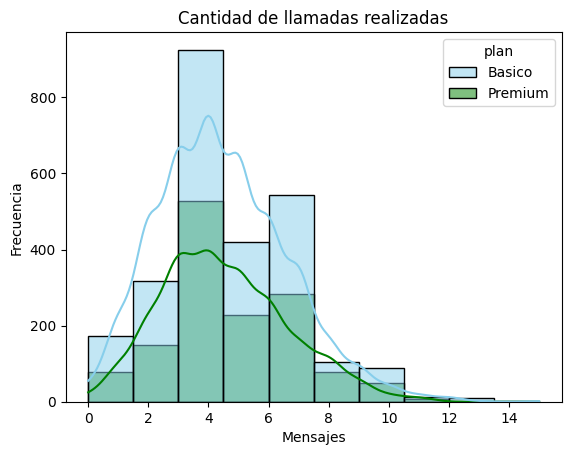

In [ ]:
# Histograma para visualizar la cant_llamadas


sns.histplot(data=user_profile, x='cant_llamadas', bins=10, hue="plan", palette=['skyblue', 'green'] ,kde=True)
plt.xlabel('Mensajes')
plt.ylabel("Frecuencia")
plt.title("Cantidad de llamadas realizadas")
plt.show()



💡Insights:
- Distribución normal con sementación a la derecha, tanto en paquete basico como el premium los clientes en mayoria hacen de 2 a 4 llamadas.

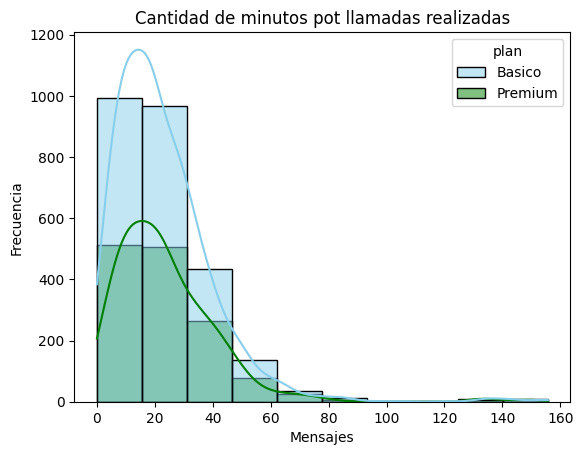

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, hue="plan", palette=['skyblue', 'green'] ,kde=True)
plt.xlabel('Mensajes')
plt.ylabel("Frecuencia")
plt.title("Cantidad de minutos pot llamadas realizadas")
plt.show()



💡Insights:
- Distribución normal con segmentación a la derecha. Tanto el paquete basico como premium tienen en mayoria llamadas con una duración de 0 a 40 minutos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

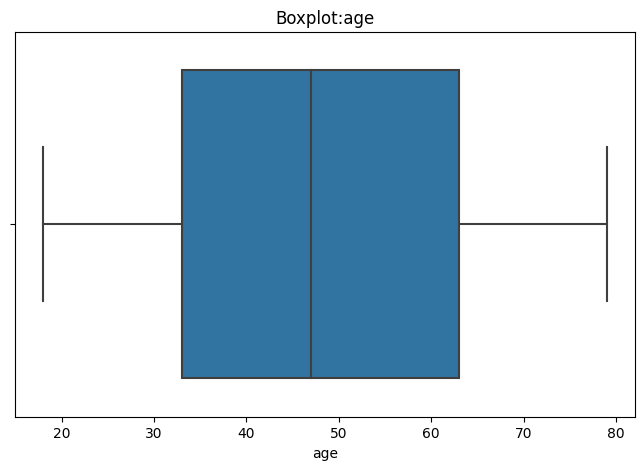

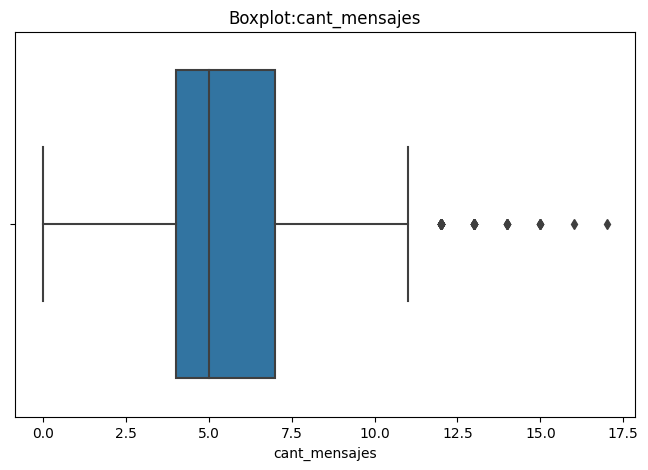

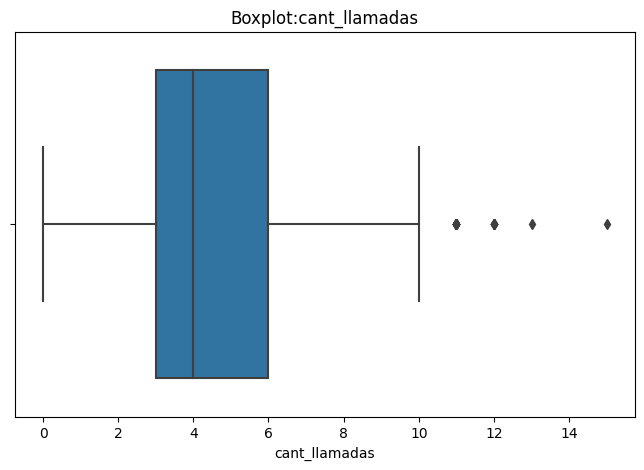

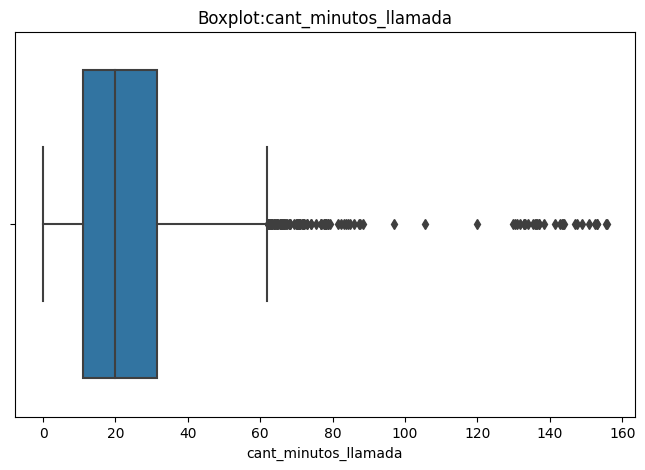

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot:{col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: no presenta valores atípicos, todos los valores están acumulados
- cant_mensajes: existen valores atípicos pero son pocos
- cant_llamadas: existen valores atípicos pero son pocos
- cant_minutos_llamada: existe una gran cantidad de valores atípicos por lo cual hay que analizar si son clientes premium

In [ ]:
# Calcular límites con el método IQR
columnas_limites = [ 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for colm in columnas_limites:
    Q1 = user_profile[colm].quantile(0.25)
    Q3 = user_profile[colm].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    outliers = user_profile[user_profile[colm]>upper]

    print(f"\n--- Análisis de outliers para {colm} ---")
    print(f"Límite superior: {upper:.2f}")
    print(f"Cantidad de outliers: {len(outliers)}")
    print(f"Porcentaje de outliers: {(len(outliers)/len(user_profile))*100:.2f}%")

    if len(outliers) > 0:
        print(f"Valores outliers encontrados: {sorted(outliers[colm].unique())}")




--- Análisis de outliers para cant_mensajes ---
Límite superior: 11.50
Cantidad de outliers: 46
Porcentaje de outliers: 1.15%
Valores outliers encontrados: [12.0, 13.0, 14.0, 15.0, 16.0, 17.0]

--- Análisis de outliers para cant_llamadas ---
Límite superior: 10.50
Cantidad de outliers: 30
Porcentaje de outliers: 0.75%
Valores outliers encontrados: [11.0, 12.0, 13.0, 15.0]

--- Análisis de outliers para cant_minutos_llamada ---
Límite superior: 61.86
Cantidad de outliers: 109
Porcentaje de outliers: 2.73%
Valores outliers encontrados: [62.11000000000001, 62.11999999999999, 62.16000000000001, 62.349999999999994, 62.42, 62.78, 62.99, 63.05, 63.14, 63.25, 63.260000000000005, 63.699999999999996, 63.830000000000005, 63.9, 64.09, 64.38000000000001, 64.53999999999999, 64.67, 64.77, 65.55, 65.56, 65.71, 65.79, 65.84, 66.03999999999999, 66.04, 66.08, 66.19999999999999, 66.52, 66.61, 66.81, 67.11, 67.32000000000001, 68.03999999999999, 68.16, 69.36, 69.9, 70.11999999999999, 70.21, 70.289999999999

In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Los datos se pueden cortar o mantener, son basntante pocos y la variacion que se emcuentra no afectan mucho el analisis estadísitico
- cant_llamadas: mantener o no outliers, porqué? Los datos se pueden cortar o mantener, son basntante pocos y la variacion que se emcuentra no afectan mucho el analisis estadísitico
- cant_minutos_llamada: mantener o no outliers, porqué? Este es caso es difícil de analizar ya que debemos de revisar si no estan relacionados con los clientes premium y ver si al tener un mejor paquete usan mas el servicio por lo tanto en este dato podriamos identidicar a los mejores clientes potenciales.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


condiciones = [
    (user_profile['cant_mensajes'] < 5) & (user_profile['cant_llamadas'] < 5),
    (user_profile['cant_mensajes'] < 10) & (user_profile['cant_llamadas'] < 10)
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')




In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
condiciones_1 = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

valores_1 = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_1, valores_1, default='Adulto Mayor')


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

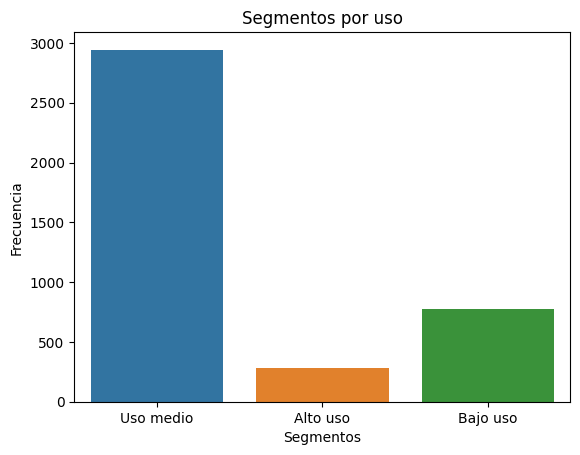

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.xlabel('Segmentos')
plt.ylabel('Frecuencia')
plt.title('Segmentos por uso')
plt.show()


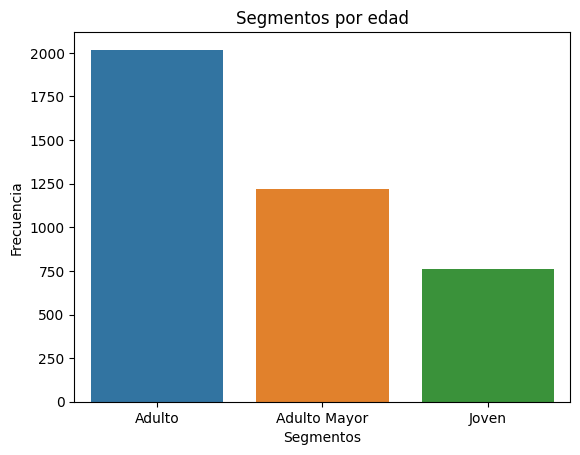

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.xlabel('Segmentos')
plt.ylabel('Frecuencia')
plt.title('Segmentos por edad')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Los datos tenian problemas en valores invalidos en ciudades, fechas imposibles, minimos imposibles en edades y mal formato de columnas de fecha.  
- En vairbles de importancia como fecha y city el porcentaje es menos del 10%, en columnas como lenght y duration es problema de interpretación pero con el analisis mas adelante se demuetra que no son valores invalidos y se puede analizar de manera sencilla


🔍 **Segmentos por Edad**
- Se identifica que la mayor cantidad de clientes tienen enctre 40 y 50 años.
- Identificamos que los clientes arriba de 60 años contratan menos el paquete premium


📊 **Segmentos por Nivel de Uso**
- Aquellos que pagan el paquete premium ya que indican que tanto pagan y el uso del servicio.
- Al mismo tiempo identidicamops el uso medio de los clientes y los benedicios que se pueden prestar por las diferentes tipos de compras


➡️ Esto sugiere que ...
El uso general de los paquetes y cuanto se utiliza en promedio, identificar aquellos clientes que utilicen mas el servicio y la especialización del paquete para el servicio del usuario.

💡 **Recomendaciones**
- Identificar cual es el uso que le da cada segmento de los usuarios e identificar que es lo que hace que cada usuario contrate un paquete
- Reconocer como hacer más atractivo el paquete para cada usuario como cantidad de mensajes, llamadas y el tiempo que tiene por llamada

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`